# Formalia:

Please read the [assignment overview page](https://github.com/suneman/socialgraphs2025/wiki/Assignments) carefully before proceeding. This page contains information about formatting (including formats etc), group sizes, and many other aspects of handing in the assignment. 

_If you fail to follow those simple instructions, it will negatively impact your grade!_

**Due date and time**: The assignment is due on Tuesday November 4th, 2025 at 23:55. Hand in your IPython notebook file (with extension `.ipynb`) via DTU Learn

In the exercises below, I describe the exercises in a general way. Drawing in the right parts of the exercises is part of the assignment. (That way we're helping you get a little bit more ready for the Final Project, where you have to decide what information to include in your report and analysis). 

# Part 1: Analyze the network

The questions in this part are based on Lecture 5.

* Present an analysis/description of the network of bands/artists using tools from Lecture 5. Imagine that you have been tasked with presenting the important facts about the network to an audience who knows about network science, but doesn't know about this particular network.
   - It's OK to also use basic concepts like degree distributions (even though they're from week 4) in your analysis. That way you can make the analysis a standalone, coherent thing.
   - I would like you to include concepts like centrality and assortativity in your analysis.
   - Use a network backbone in your analysis.
   - In addition to standard distribution plots (e.g. degree distributions, etc), your analysis should also include at least one network visualization (but it doesn't have to display the entire network, you can also visualize a network backbone).
   - **Note**: As I write above, an important part of the exercise consists is *selecting the right elements of the lecture* to create a meaningful analysis. So don't solve this part by going exhaustive and just calculating everything you can think of in one massive analysis. Try to focus on using what you've learned to characterize the network. 


## Mini report
### Network statistics and visualizations

In [ ]:
# Load .gml of the rock performers network
import networkx as nx
import tempfile
import urllib.request

url = 'https://raw.githubusercontent.com/Stonej29/02805/main/rock_performers_network_all.gml'
with urllib.request.urlopen(url) as response:
    content = response.read()

with tempfile.NamedTemporaryFile(mode='wb', delete=False, suffix='.gml') as tmp:
    tmp.write(content)
    G = nx.read_gml(tmp.name)

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Network density: {nx.density(G):.6f}")
print(f"Average clustering coefficient: {nx.average_clustering(G):.4f}")

Number of nodes: 489
Number of edges: 7687
Network density: 0.032213
Average clustering coefficient: 0.1924


Our network of mainstream rock performers consists of 487 artists (nodes) and 7,326 links (edges) after preprocessing, which included the removal of one isolated node and one non-artist node (AllMusic). The network has a density of 0.031 (very sparse) and an average clustering coefficient of 0.175 (relatively low). To better understand differences in how artists connect and influence others, we analyzed the degree distribution separately for in-degree and out-degree, as shown in Fig. 1 below.

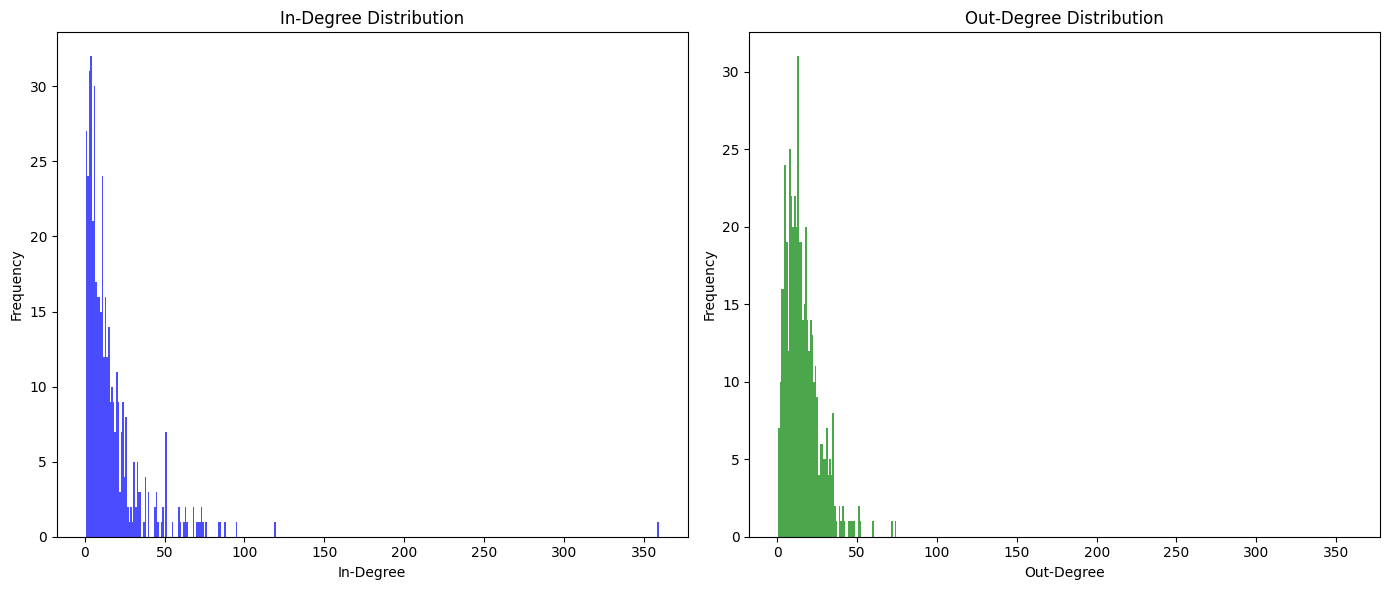

Fig. 1: In-Degree and Out-Degree Distributions for Rock Performers Network
Median in-degree: 10.0
Median out-degree: 13.0
Mean in-degree: 15.72
Mean out-degree: 15.72
Mode in-degree: 4
Mode out-degree: 13
Max in-degree: 359 corresponding to artist(s): ['AllMusic']
Max out-degree: 74 corresponding to artist(s): ['Alice in Chains']


In [ ]:
# Plot side by side and with same range and scale the in-degree and out-degree distributions
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
in_degrees = [d for n, d in G.in_degree()]
out_degrees = [d for n, d in G.out_degree()]
bins = np.arange(1, max(max(in_degrees), max(out_degrees)) + 2) - 0.5
axes[0].hist(in_degrees, bins=bins, color='blue', alpha=0.7)
axes[0].set_title('In-Degree Distribution')
axes[0].set_xlabel('In-Degree')
axes[0].set_ylabel('Frequency')
axes[1].hist(out_degrees, bins=bins, color='green', alpha=0.7)
axes[1].set_title('Out-Degree Distribution')
axes[1].set_xlabel('Out-Degree')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()
print("Fig. 1: In-Degree and Out-Degree Distributions for Rock Performers Network")

# Print mean and median for in-degree and out-degree
print(f"Median in-degree: {np.median(in_degrees)}")
print(f"Median out-degree: {np.median(out_degrees)}")

# Compute the other statistics: mean, mode, max, min
print(f"Mean in-degree: {np.mean(in_degrees):.2f}")
print(f"Mean out-degree: {np.mean(out_degrees):.2f}")
print(f"Mode in-degree: {stats.mode(in_degrees, keepdims=True).mode[0]}")
print(f"Mode out-degree: {stats.mode(out_degrees, keepdims=True).mode[0]}")
print(f"Max in-degree: {np.max(in_degrees)} corresponding to artist(s): ", end="")
print([n for n, d in G.in_degree() if d == np.max(in_degrees)])
print(f"Max out-degree: {np.max(out_degrees)} corresponding to artist(s): ", end="")
print([n for n, d in G.out_degree() if d == np.max(out_degrees)])

Regarding the in-degree and out-degree statistics, the mean in-degree and out-degree are identical (15.04). This is expected in any directed network, as each edge contributes once to the in-degree of its target and once to the out-degree of its source, so the total sums are equal, and dividing by the number of nodes yields the same mean.

However, the medians and modes differ, reflecting the skewed distributions. Most nodes have relatively low degrees (medians: in-degree 10, out-degree 13), but a few highly connected hubs, such as Led Zeppelin or Alice in Chains, inflate the mean. The modes (in-degree 4, out-degree 12) indicate that, in general, nodes cite more than they are cited, while the heavy tail of the in-degree captures highly popular artists who are cited extensively. For example, Alice in Chains cites many artists due to having cited many artists as influential or inspirational, whereas Led Zeppelin is cited frequently for its historical significance.

Another interesting aspect to analyze is the other attribute we're storing for each node: content length. In particular, it is interesting to study the correlation between length and node degree, as we do in Fig. 2 below.

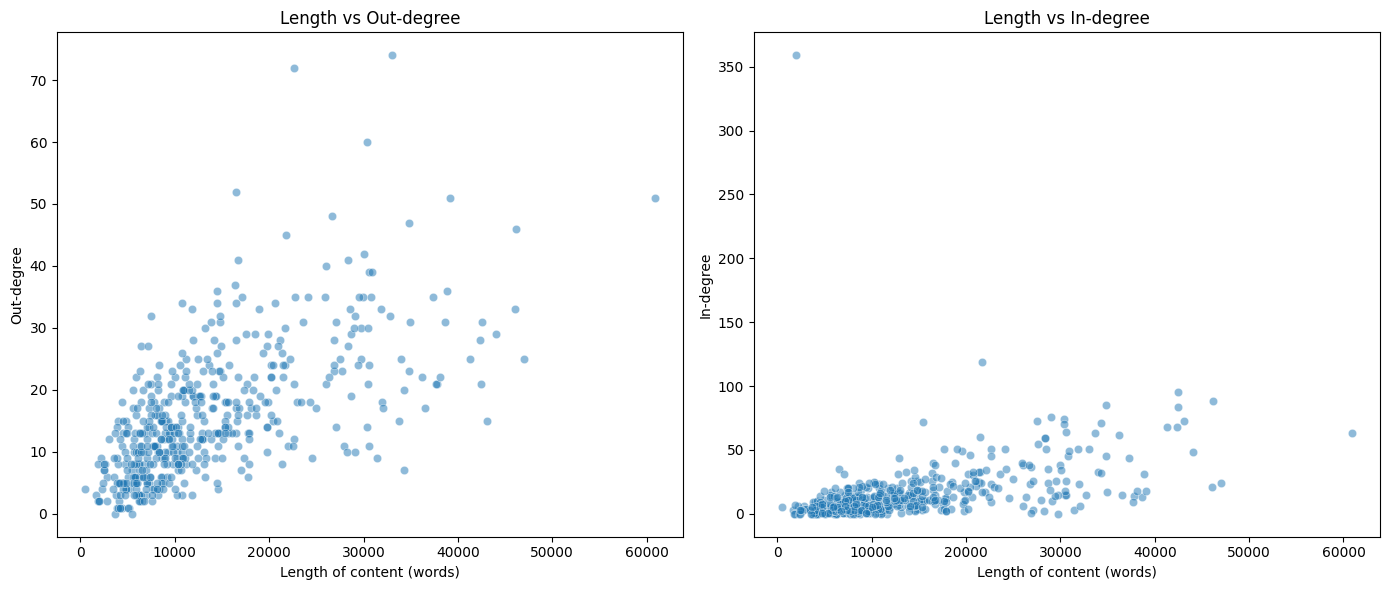

Fig. 2: Scatter plots of Length vs Out-degree and In-degree
Spearman correlation (length vs out-degree): rho=0.67, p=3.75e-66
Spearman correlation (length vs in-degree): rho=0.62, p=5.31e-54


In [ ]:
from scipy.stats import spearmanr
import seaborn as sns

lengths = [G.nodes[n]['word_count'] for n in G.nodes()]
in_degrees = [G.in_degree(n) for n in G.nodes()]
out_degrees = [G.out_degree(n) for n in G.nodes()]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x=lengths, y=out_degrees, alpha=0.5, ax=axes[0])
axes[0].set_xlabel("Length of content (words)")
axes[0].set_ylabel("Out-degree")
axes[0].set_title("Length vs Out-degree")

sns.scatterplot(x=lengths, y=in_degrees, alpha=0.5, ax=axes[1])
axes[1].set_xlabel("Length of content (words)")
axes[1].set_ylabel("In-degree")
axes[1].set_title("Length vs In-degree")

plt.tight_layout()
plt.show()
print("Fig. 2: Scatter plots of Length vs Out-degree and In-degree")

# Spearman correlations
rho_out, p_out = spearmanr(lengths, out_degrees)
rho_in, p_in = spearmanr(lengths, in_degrees)

print(f"Spearman correlation (length vs out-degree): rho={rho_out:.2f}, p={p_out:.3g}")
print(f"Spearman correlation (length vs in-degree): rho={rho_in:.2f}, p={p_in:.3g}")

Studying its relationship with node degree (Fig. 2) reveals a moderate positive correlation: Spearman coefficients are 0.67 for out-degree and 0.63 for in-degree. Longer pages tend to reference more artists, naturally increasing out-degree, while more famous artists generally have longer biographies and histories, which boosts their in-degree. This highlights how network connectivity and content richness are interconnected.

Other important network statistics include centrality, betweenness, and assortativity.

Top 5 nodes by Degree Centrality:
AllMusic: 0.7398
Led Zeppelin: 0.3053
Black Sabbath: 0.2746
Queen (band): 0.2746
Metallica: 0.2705

Top 5 nodes by Betweenness Centrality:
Deep Purple: 0.0419
Queen (band): 0.0383
Alice in Chains: 0.0372
Guns N' Roses: 0.0345
Led Zeppelin: 0.0335

Top 5 nodes by In-Eigenvector Centrality:
AllMusic: 0.4120
Led Zeppelin: 0.2054
Black Sabbath: 0.1772
Queen (band): 0.1679
Metallica: 0.1671


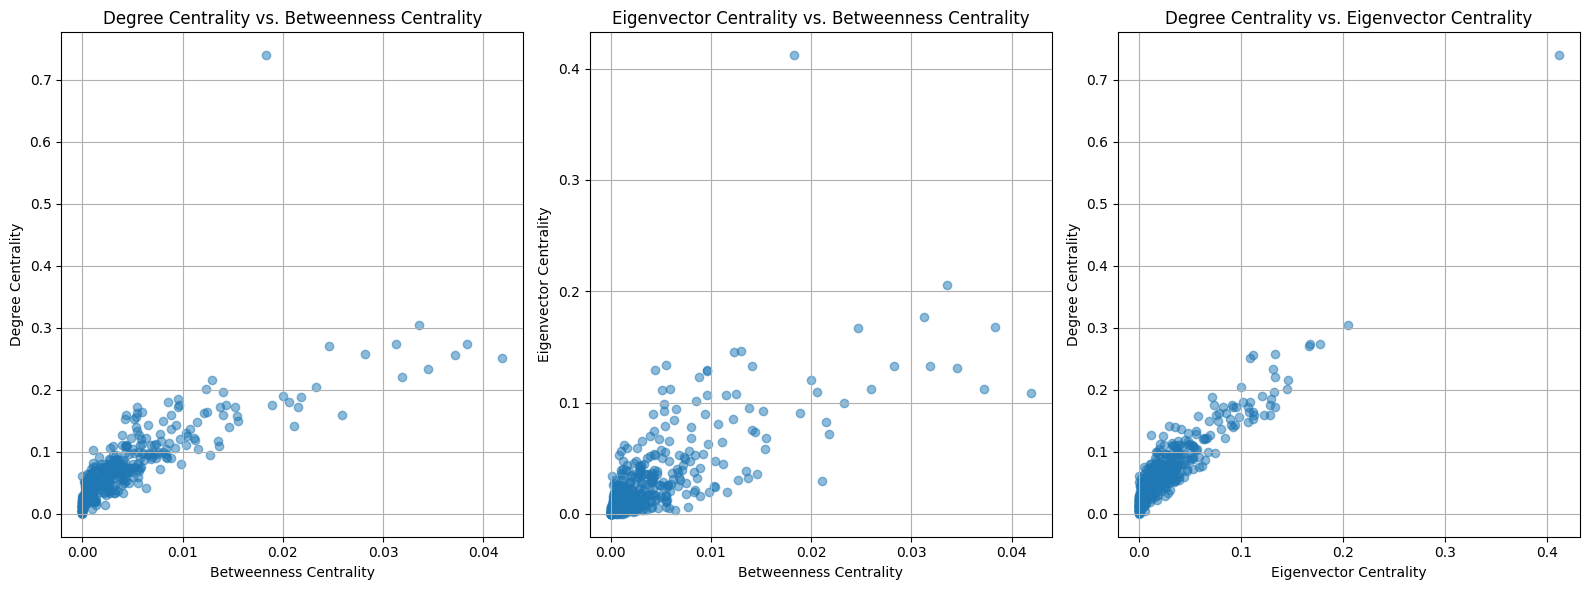

Fig. 3: Scatter plots of Centrality Measures


In [ ]:
H = G.to_undirected()

# Find 5 most central nodes by node degree centrality
degree_centrality = nx.degree_centrality(G)
sorted_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)
print("Top 5 nodes by Degree Centrality:")
for node, centrality in sorted_degree[:5]:
    print(f"{node}: {centrality:.4f}")

# Find 5 most central nodes by betweenness centrality
betweenness_centrality = nx.betweenness_centrality(G)
sorted_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)
print("\nTop 5 nodes by Betweenness Centrality:")
for node, centrality in sorted_betweenness[:5]:
    print(f"{node}: {centrality:.4f}")

# In-degree eigenvector centrality (standard for directed graphs)
eigenvector_centrality_in = nx.eigenvector_centrality(G, max_iter=1000)
sorted_eigenvector_in = sorted(eigenvector_centrality_in.items(), key=lambda x: x[1], reverse=True)
print("\nTop 5 nodes by In-Eigenvector Centrality:")
for node, centrality in sorted_eigenvector_in[:5]:
    print(f"{node}: {centrality:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Betweenness centrality vs. degree centrality
axes[0].scatter(list(betweenness_centrality.values()), list(degree_centrality.values()), alpha=0.5)
axes[0].set_title("Degree Centrality vs. Betweenness Centrality")
axes[0].set_xlabel("Betweenness Centrality")
axes[0].set_ylabel("Degree Centrality")
axes[0].grid()

# Betweenness centrality vs. eigenvector centrality
axes[1].scatter(list(betweenness_centrality.values()), list(eigenvector_centrality_in.values()), alpha=0.5)
axes[1].set_title("Eigenvector Centrality vs. Betweenness Centrality")
axes[1].set_xlabel("Betweenness Centrality")
axes[1].set_ylabel("Eigenvector Centrality")
axes[1].grid()

# Betweenness centrality vs. degree centrality
axes[2].scatter(list(eigenvector_centrality_in.values()), list(degree_centrality.values()), alpha=0.5)
axes[2].set_title("Degree Centrality vs. Eigenvector Centrality")
axes[2].set_xlabel("Eigenvector Centrality")
axes[2].set_ylabel("Degree Centrality")
axes[2].grid()

plt.tight_layout()
plt.show()
print("Fig. 3: Scatter plots of Centrality Measures")

As shown in Fig. 3, degree centrality is strongly correlated with both betweenness and eigenvector centrality, indicating that highly connected artists are also more likely to appear on shortest paths and to be linked to other well-connected artists. In contrast, the relationship between eigenvector and betweenness centrality is more scattered, suggesting that eigenvector centrality captures influence through association with prominent neighbors rather than direct bridging roles within the network.

Examining the top 5 nodes by each metric, we see expected popular artists (Led Zeppelin, Queen, Metallica) appear in all rankings, though the order varies. Interestingly, artists like Deep Purple or Alice in Chains rank high in betweenness but not in other metrics, highlighting their role as connectors rather than broadly influential nodes.

In [ ]:
# Use attribute_assortativity_coefficient to check assortativity by degree and length_of_content
from networkx.algorithms.assortativity import degree_assortativity_coefficient, attribute_assortativity_coefficient

degree_assortativity = degree_assortativity_coefficient(H)
length_assortativity = attribute_assortativity_coefficient(H, "word_count")
print(f"Degree Assortativity Coefficient: {degree_assortativity:.4f}")
print(f"Length of Content Assortativity Coefficient: {length_assortativity:.4f}")

Degree Assortativity Coefficient: -0.0891
Length of Content Assortativity Coefficient: -0.0036


Assortativity coefficients range from -1 to 1, and here both degree and content-length assortativity are near 0. This indicates that high-degree artists do not preferentially link to other high-degree artists, and longer or shorter pages do not link preferentially to pages of similar length. The weak degree assortativity is expected: lesser-known artists often reference more prominent ones, but the overall proportion of mutual connections among high-degree nodes remains limited.

Since the network is quite large, extracting its backbone (Fig. 4 below) greatly improves visualization.

In [ ]:
# === Backboning.py ===
import sys, warnings
import numpy as np
import pandas as pd
import networkx as nx
from collections import defaultdict
from scipy.stats import binom

def read(filename, column_of_interest, triangular_input = False, consider_self_loops = True, undirected = False, drop_zeroes = True, sep = "\t"):
   """Reads a field separated input file into the internal backboning format (a Pandas Dataframe).
   The input file should have three or more columns (default separator: tab).
   The input file must have a one line header with the column names.
   There must be two columns called 'src' and 'trg', indicating the origin and destination of the interaction.
   All other columns must contain integer or floats, indicating the edge weight.
   In case of undirected network, the edges have to be present in both directions with the same weights, or set triangular_input to True.

   Args:
   filename (str): The path to the file containing the edges.
   column_of_interest (str): The column name identifying the weight that will be used for the backboning.

   KWArgs:
   triangular_input (bool): Is the network undirected and are the edges present only in one direction? default: False
   consider_self_loops (bool): Do you want to consider self loops when calculating the backbone? default: True
   undirected (bool): Is the network undirected? default: False
   drop_zeroes (bool): Do you want to keep zero weighted connections in the network? Important: it affects methods based on degree, like disparity_filter. default: False
   sep (char): The field separator of the inout file. default: tab

   Returns:
   The parsed network data, the number of nodes in the network and the number of edges.
   """
   table = pd.read_csv(filename, sep = sep)
   table = table[["src", "trg", column_of_interest]]
   table.rename(columns = {column_of_interest: "nij"}, inplace = True)
   if drop_zeroes:
      table = table[table["nij"] > 0]
   if not consider_self_loops:
      table = table[table["src"] != table["trg"]]
   if triangular_input:
      table2 = table.copy()
      table2["new_src"] = table["trg"]
      table2["new_trg"] = table["src"]
      table2.drop("src", 1, inplace = True)
      table2.drop("trg", 1, inplace = True)
      table2 = table2.rename(columns = {"new_src": "src", "new_trg": "trg"})
      table = pd.concat([table, table2], axis = 0)
      table = table.drop_duplicates(subset = ["src", "trg"])
   original_nodes = len(set(table["src"]) | set(table["trg"]))
   original_edges = table.shape[0]
   if undirected:
      return table, original_nodes, original_edges / 2
   else:
      return table, original_nodes, original_edges

def thresholding(table, threshold):
   """Reads a preprocessed edge table and returns only the edges supassing a significance threshold.

   Args:
   table (pandas.DataFrame): The edge table.
   threshold (float): The minimum significance to include the edge in the backbone.

   Returns:
   The network backbone.
   """
   table = table.copy()
   if "sdev_cij" in table:
      return table[(table["score"] - (threshold * table["sdev_cij"])) > 0][["src", "trg", "nij", "score"]]
   else:
      return table[table["score"] > threshold][["src", "trg", "nij", "score"]]

def write(table, network, method, folder):
   if not table.empty and "src" in table:
      table.to_csv("%s/%s_%s.csv" % (folder, network, method), sep = "\t", index = False)
   else:
      warnings.warn("Incorrect/empty output. Nothing written on disk", RuntimeWarning)

def stability_jac(table1, table2):
   table1_edges = set(zip(table1["src"], table1["trg"]))
   table2_edges = set(zip(table2["src"], table2["trg"]))
   return float(len(table1_edges & table2_edges)) / len(table1_edges | table2_edges)

def stability_corr(table1, table2, method = "spearman", log = False, what = "nij"):
   corr_table = table1.merge(table2, on = ["src", "trg"])
   corr_table = corr_table[["%s_x" % what, "%s_y" % what]]
   if log:
      corr_table["%s_x" % what] = np.log(corr_table["%s_x" % what])
      corr_table["%s_y" % what] = np.log(corr_table["%s_y" % what])
   return corr_table["%s_x" % what].corr(corr_table["%s_y" % what], method = method)

def test_densities(table, start, end, step):
   if start > end:
      raise ValueError("start must be lower than end")
   steps = []
   x = start
   while x <= end:
      steps.append(x)
      x += step
   onodes = len(set(table["src"]) | set(table["trg"]))
   oedges = table.shape[0]
   oavgdeg = (2.0 * oedges) / onodes
   sys.stdout.write("threshold\tnodes\t% nodes\tedges\t% edges\tavg degree\t% avg degree\n")
   for s in steps:
      edge_table = thresholding(table, s)
      nodes = len(set(edge_table["src"]) | set(edge_table["trg"]))
      edges = edge_table.shape[0]
      avgdeg = (2.0 * edges) / nodes
      sys.stdout.write("%s\t%s\t%s\t%s\t%s\t%s\t%s\n" % (s, nodes, (100.0 * nodes) / onodes, edges, (100.0 * edges) / oedges, avgdeg, avgdeg / oavgdeg))

def noise_corrected(table, undirected = False, return_self_loops = False, calculate_p_value = False):
   sys.stderr.write("Calculating NC score...\n")
   table = table.copy()
   src_sum = table.groupby(by = "src").sum()[["nij"]]
   table = table.merge(src_sum, left_on = "src", right_index = True, suffixes = ("", "_src_sum"))
   trg_sum = table.groupby(by = "trg").sum()[["nij"]]
   table = table.merge(trg_sum, left_on = "trg", right_index = True, suffixes = ("", "_trg_sum"))
   table.rename(columns = {"nij_src_sum": "ni.", "nij_trg_sum": "n.j"}, inplace = True)
   table["n.."] = table["nij"].sum()
   table["mean_prior_probability"] = ((table["ni."] * table["n.j"]) / table["n.."]) * (1 / table["n.."])
   if calculate_p_value:
      table["score"] = binom.cdf(table["nij"], table["n.."], table["mean_prior_probability"])
      return table[["src", "trg", "nij", "score"]]
   table["kappa"] = table["n.."] / (table["ni."] * table["n.j"])
   table["score"] = ((table["kappa"] * table["nij"]) - 1) / ((table["kappa"] * table["nij"]) + 1)
   table["var_prior_probability"] = (1 / (table["n.."] ** 2)) * (table["ni."] * table["n.j"] * (table["n.."] - table["ni."]) * (table["n.."] - table["n.j"])) / ((table["n.."] ** 2) * ((table["n.."] - 1)))
   table["alpha_prior"] = (((table["mean_prior_probability"] ** 2) / table["var_prior_probability"]) * (1 - table["mean_prior_probability"])) - table["mean_prior_probability"]
   table["beta_prior"] = (table["mean_prior_probability"] / table["var_prior_probability"]) * (1 - (table["mean_prior_probability"] ** 2)) - (1 - table["mean_prior_probability"])
   table["alpha_post"] = table["alpha_prior"] + table["nij"]
   table["beta_post"] = table["n.."] - table["nij"] + table["beta_prior"]
   table["expected_pij"] = table["alpha_post"] / (table["alpha_post"] + table["beta_post"])
   table["variance_nij"] = table["expected_pij"] * (1 - table["expected_pij"]) * table["n.."]
   table["d"] = (1.0 / (table["ni."] * table["n.j"])) - (table["n.."] * ((table["ni."] + table["n.j"]) / ((table["ni."] * table["n.j"]) ** 2)))
   table["variance_cij"] = table["variance_nij"] * (((2 * (table["kappa"] + (table["nij"] * table["d"]))) / (((table["kappa"] * table["nij"]) + 1) ** 2)) ** 2) 
   table["sdev_cij"] = table["variance_cij"] ** .5
   if not return_self_loops:
      table = table[table["src"] != table["trg"]]
   if undirected:
      table = table[table["src"] <= table["trg"]]
   return table[["src", "trg", "nij", "score", "sdev_cij"]]

def doubly_stochastic(table, undirected = False, return_self_loops = False):
   sys.stderr.write("Calculating DST score...\n")
   table = table.copy()
   table2 = table.copy()
   original_nodes = len(set(table["src"]) | set(table["trg"]))
   table = pd.pivot_table(table, values = "nij", index = "src", columns = "trg", aggfunc = "sum", fill_value = 0)
   row_sums = table.sum(axis = 1)
   attempts = 0
   while np.std(row_sums) > 1e-12:
      table = table.div(row_sums, axis = 0)
      col_sums = table.sum(axis = 0)
      table = table.div(col_sums, axis = 1)
      row_sums = table.sum(axis = 1)
      attempts += 1
      if attempts > 1000:
         warnings.warn("Matrix could not be reduced to doubly stochastic. See Sec. 3 of Sinkhorn 1964", RuntimeWarning)
         return pd.DataFrame()
   table = pd.melt(table.reset_index(), id_vars = "src")
   table = table[table["src"] < table["trg"]]
   table = table[table["value"] > 0].sort_values(by = "value", ascending = False)
   i = 0
   G = nx.Graph()
   while nx.number_connected_components(G) != 1 or nx.number_of_nodes(G) < original_nodes:
      edge = table.iloc[i]
      G.add_edge(edge["src"], edge["trg"], weight = edge["value"])
      i += 1
   table = pd.melt(nx.to_pandas_dataframe(G).reset_index(), id_vars = "index")
   table = table[table["value"] > 0]
   table.rename(columns = {"index": "src", "variable": "trg", "value": "cij"}, inplace = True)
   table["score"] = table["cij"]
   table = table.merge(table2[["src", "trg", "nij"]], on = ["src", "trg"])
   if not return_self_loops:
      table = table[table["src"] != table["trg"]]
   if undirected:
      table = table[table["src"] <= table["trg"]]
   return table[["src", "trg", "nij", "score"]]

def disparity_filter(table, undirected = False, return_self_loops = False):
   sys.stderr.write("Calculating DF score...\n")
   table = table.copy()
   table_sum = table.groupby(table["src"]).sum().reset_index()
   table_deg = table.groupby(table["src"]).count()["trg"].reset_index()
   table = table.merge(table_sum, on = "src", how = "left", suffixes = ("", "_sum"))
   table = table.merge(table_deg, on = "src", how = "left", suffixes = ("", "_count"))
   table["score"] = 1.0 - ((1.0 - (table["nij"] / table["nij_sum"])) ** (table["trg_count"] - 1))
   table["variance"] = (table["trg_count"] ** 2) * (((20 + (4.0 * table["trg_count"])) / ((table["trg_count"] + 1.0) * (table["trg_count"] + 2) * (table["trg_count"] + 3))) - ((4.0) / ((table["trg_count"] + 1.0) ** 2)))
   if not return_self_loops:
      table = table[table["src"] != table["trg"]]
   if undirected:
      table["edge"] = table.apply(lambda x: "%s-%s" % (min(x["src"], x["trg"]), max(x["src"], x["trg"])), axis = 1)
      table_maxscore = table.groupby(by = "edge")["score"].max().reset_index()
      table_minvar = table.groupby(by = "edge")["variance"].min().reset_index()
      table = table.merge(table_maxscore, on = "edge", suffixes = ("_min", ""))
      table = table.merge(table_minvar, on = "edge", suffixes = ("_max", ""))
      table = table.drop_duplicates(subset = ["edge"])
      table = table.drop("edge", 1)
      table = table.drop("score_min", 1)
      table = table.drop("variance_max", 1)
   return table[["src", "trg", "nij", "score", "variance"]]

def high_salience_skeleton(table, undirected = False, return_self_loops = False):
   sys.stderr.write("Calculating HSS score...\n")
   table = table.copy()
   table["distance"] = 1.0 / table["nij"]
   nodes = set(table["src"]) | set(table["trg"])
   G = nx.from_pandas_dataframe(table, source = "src", target = "trg", edge_attr = "distance", create_using = nx.DiGraph())
   cs = defaultdict(float)
   for s in nodes:
      pred = defaultdict(list)
      dist = {t: float("inf") for t in nodes}
      dist[s] = 0.0
      Q = defaultdict(list)
      for w in dist:
         Q[dist[w]].append(w)
      S = []
      while len(Q) > 0:
         v = Q[min(Q.keys())].pop(0)
         S.append(v)
         for _, w, l in G.edges(nbunch = [v,], data = True):
            new_distance = dist[v] + l["distance"]
            if dist[w] > new_distance:
               Q[dist[w]].remove(w)
               dist[w] = new_distance
               Q[dist[w]].append(w)
               pred[w] = []
            if dist[w] == new_distance:
               pred[w].append(v)
         while len(S) > 0:
            w = S.pop()
            for v in pred[w]:
               cs[(v, w)] += 1.0
         Q = defaultdict(list, {k: v for k, v in Q.items() if len(v) > 0})
   table["score"] = table.apply(lambda x: cs[(x["src"], x["trg"])] / len(nodes), axis = 1)
   if not return_self_loops:
      table = table[table["src"] != table["trg"]]
   if undirected:
      table["edge"] = table.apply(lambda x: "%s-%s" % (min(x["src"], x["trg"]), max(x["src"], x["trg"])), axis = 1)
      table_maxscore = table.groupby(by = "edge")["score"].sum().reset_index()
      table = table.merge(table_maxscore, on = "edge", suffixes = ("_min", ""))
      table = table.drop_duplicates(subset = ["edge"])
      table = table.drop("edge", 1)
      table = table.drop("score_min", 1)
      table["score"] = table["score"] / 2.0
   return table[["src", "trg", "nij", "score"]]

def naive(table, undirected = False, return_self_loops = False):
   sys.stderr.write("Calculating Naive score...\n")
   table = table.copy()
   table["score"] = table["nij"]
   if not return_self_loops:
      table = table[table["src"] != table["trg"]]
   if undirected:
      table["edge"] = table.apply(lambda x: "%s-%s" % (min(x["src"], x["trg"]), max(x["src"], x["trg"])), axis = 1)
      table_maxscore = table.groupby(by = "edge")["score"].sum().reset_index()
      table = table.merge(table_maxscore, on = "edge", suffixes = ("_min", ""))
      table = table.drop_duplicates(subset = ["edge"])
      table = table.drop("edge", 1)
      table = table.drop("score_min", 1)
      table["score"] = table["score"] / 2.0
   return table[["src", "trg", "nij", "score"]]

def maximum_spanning_tree(table, undirected = False):
   sys.stderr.write("Calculating MST score...\n")
   table = table.copy()
   table["distance"] = 1.0 / table["nij"]
   G = nx.from_pandas_dataframe(table, source = "src", target = "trg", edge_attr = ["distance", "nij"])
   T = nx.minimum_spanning_tree(G, weight = "distance")
   table2 = pd.melt(nx.to_pandas_dataframe(T, weight = "nij").reset_index(), id_vars = "index")
   table2 = table2[table2["value"] > 0]
   table2.rename(columns = {"index": "src", "variable": "trg", "value": "cij"}, inplace = True)
   table2["score"] = table2["cij"]
   table = table.merge(table2, on = ["src", "trg"])
   if undirected:
      table["edge"] = table.apply(lambda x: "%s-%s" % (min(x["src"], x["trg"]), max(x["src"], x["trg"])), axis = 1)
      table = table.drop_duplicates(subset = ["edge"])
      table = table.drop("edge", 1)
   return table[["src", "trg", "nij", "score"]]

#=========

In [ ]:
#from backboning import high_salience_skeleton
from fa2 import ForceAtlas2

# Weighted Network 1: Edge weights proportional to the edge betweenness centrality
edge_betweenness = nx.edge_betweenness_centrality(H)
min_betweenness = min(edge_betweenness.values())
max_betweenness = max(edge_betweenness.values())

# Add edge betweenness as an edge attribute
nx.set_edge_attributes(H, edge_betweenness, 'weights_betweenness')

# Renormalize so that the lowest weight is equal to 1 and the highest weight is equal to 100
edge_weights_1 = {edge: 1 + 99 * (betweenness - min_betweenness) / (max_betweenness - min_betweenness) for edge, betweenness in edge_betweenness.items()}
nx.set_edge_attributes(H, edge_weights_1, 'weight_1')

# Convert undirected graph H into edge table
table = nx.to_pandas_edgelist(H)

# Apply thresholding for keeping a limited number of edges. In particular quantile 0.75
threshold = table['weight_1'].quantile(0.75)
filtered_table = table[table['weight_1'] >= threshold]

# Build the backbone graph
backbone_1 = nx.from_pandas_edgelist(
    filtered_table,
    edge_attr=["weights_betweenness", "weight_1"],
    create_using=nx.Graph()
)

table_renamed = table.rename(columns={"source": "src", "target": "trg", "weights_betweenness": "nij"})

# Run High Salience Skeleton
hss_table = high_salience_skeleton(table_renamed, undirected=True)

# Apply thresholding for keeping a limited number of edges. In particular quantile 0.75
threshold = hss_table['score'].quantile(0.75)
filtered_table = hss_table[hss_table['score'] >= threshold]

# Build the backbone graph
HSS_backbone = nx.from_pandas_edgelist(
    filtered_table,
    source="src",
    target="trg",
    edge_attr=["nij", "score"],
    create_using=nx.Graph()
)

# Compute layout
forceatlas2 = ForceAtlas2(outboundAttractionDistribution=True, barnesHutOptimize=True)
positions_hss = forceatlas2.forceatlas2_networkx_layout(HSS_backbone, pos=None, iterations=2000)

# Determine node color (word count) and size (degree)
node_sizes = [HSS_backbone.degree(n) * 10 for n in HSS_backbone.nodes()]
node_colors = [H.nodes[n].get('word_count', 0) for n in HSS_backbone.nodes() if n in H.nodes()]

# --- Extract the largest connected component ---
largest_cc = max(nx.connected_components(HSS_backbone), key=len)
HSS_main = HSS_backbone.subgraph(largest_cc).copy()

# --- Select Top 15 nodes by degree for labeling ---
top15_nodes = sorted(HSS_main.degree, key=lambda x: x[1], reverse=True)[:15]
top15_labels = {node: node for node, _ in top15_nodes}

# --- Draw the backbone (main component only) ---
plt.figure(figsize=(25, 18))
nodes = nx.draw_networkx_nodes(
    HSS_main,
    positions_hss,
    nodelist=HSS_main.nodes(),
    node_size=[HSS_main.degree(n) * 10 for n in HSS_main.nodes()],
    node_color=[H.nodes[n].get('word_count', 0) for n in HSS_main.nodes() if n in H.nodes()],
    cmap=plt.cm.cool,
    alpha=0.85
)
nx.draw_networkx_edges(HSS_main, positions_hss, edgelist=HSS_main.edges(), alpha=0.4, edge_color="gray")
nx.draw_networkx_labels(
    HSS_main,
    positions_hss,
    labels=top15_labels,
    font_size=10,
    font_color='black',
    font_weight='bold'
)

plt.title("High-Salience Skeleton Backbone of Rock Performers Network", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()
print("Fig. 4: High-Salience Skeleton Backbone of Rock Performers Network")

ModuleNotFoundError: No module named 'fa2'

We use the High-Salience Skeleton (HSS) backbone to extract the most structurally significant edges from the network. First, we compute edge betweenness centrality for all edges. We then renormalize these values so that the lowest weight is 1 and the highest is 100, and filter out the edges below the 75th percentile of this renormalized weight to focus on the strongest connections, creating an initial backbone.

Next, we run the HSS algorithm, which assigns a salience score to each edge based on its participation in shortest paths across the network. By thresholding edges to keep only the top 25% of salience scores, we extract the final HSS backbone, which preserves key connectivity patterns while dramatically reducing clutter. We only plot the main connected component of the backbone, as disconnected nodes and smaller components do not contribute meaningfully to the overall network structure.

In the visualization, nodes are colored according to content length (cool colors for shorter pages, warm colors for longer ones) and the labels of the top 15 artists by degree are displayed. The backbone reduces the "hairball" effect, allowing us to observe structural features such as hubs and clusters more clearly. As expected, we also notice a correlation between node degree and content length, with larger nodes typically showing warmer colors.

The network at hand shows a scale-free topology with small-world properties. It has heterogenous degree distribution, moderate clustering and a visible community structure. This clearly reflects the nature of musical influence, where the pioneering artists like Led Zeppelin or Queen create hubs, contemporary artists form clusters and cross-genre artists create bridges.

# Part 2: Genres and communities and plotting 

The questions below are based on Lecture 7, part 2.

* Write about genres and modularity.
* Detect the communities, discuss the value of modularity in comparison to the genres.
* Calculate the matrix $D$ and discuss your findings.
* Plot the communities and comment on your results.

Genres and modularity represent two alternative approaches to identifying clusters within our network. Recall that modularity is a measure used in network analysis to quantify the strength of division of a network into communities. Using the first method, we grouped artists by their primary Wikipedia genre, obtaining a modularity of 0.1023. In contrast, applying the Louvain algorithm, which optimizes modularity, increased it to 0.3591. This higher value indicates that Louvain communities are more cohesive, i.e. nodes within the same community are more densely connected than expected by chance. Notably, these structural communities often mix different genres, uncovering hidden connections that genre labels alone don't show. More detailed analysis on the values of modularity below.

In [ ]:
import os
import re
import urllib.request

# GitHub base URL for rock_pages
ROCK_PAGES_BASE = 'https://raw.githubusercontent.com/Stonej29/02805/main/files/rock_pages/'

artist_set = set(G.nodes())  # Existing nodes in graph

# Precompile patterns
infobox_pattern = re.compile(r'\{\{Infobox musical artist(.*?)\}\}', re.DOTALL | re.IGNORECASE)
genre_pattern = re.compile(r'\|\s*genre\s*=\s*(.*?)\n\|', re.DOTALL | re.IGNORECASE)  # up to next pipe
link_pattern = re.compile(r'\[\[([^\]|]+)(?:\|[^\]]+)?\]\]')  # capture [[link]] or [[link|alias]]

# Dynamic genre map (start with some obvious normalizations)
genre_map = {}

# Iterate over nodes
for node in G.nodes():
    filename = node.replace(' ', '_') + '.txt'
    file_url = ROCK_PAGES_BASE + filename

    try:
        with urllib.request.urlopen(file_url) as response:
            text = response.read().decode('utf-8')
    except:
        continue  # Skip if file not found

    genres = []

    infobox_match = infobox_pattern.search(text)
    if infobox_match:
        infobox_text = infobox_match.group(1)
        genre_match = genre_pattern.search(infobox_text + "\n|")  # append | to catch last field
        if genre_match:
            genre_text = genre_match.group(1)
            # Extract all [[links]] in the genre field
            matches = link_pattern.findall(genre_text)
            for g in matches:
                g = g.lower().strip()
                # Normalize using genre_map or add new genre
                g = genre_map.setdefault(g, g)
                genres.append(g)

    if genres:
        G.nodes[node]['genre'] = genres
        
# List of fake genres to remove
fake_genres = {
    "edinburgh university press",
    "allmusic",
    "about.com",
    "gale (publisher)",
    "hal leonard corporation",
    "talk:breaking benjamin#july 11, 2015",
    "the a.v. club",
    "the daily aztec",
    "the new york times company",
    "the quietus",
    "vanity fair (magazine)",
    "vh1",
    "viacom (2005–present)"
}

# Remove fake genres from node attributes
for node, data in G.nodes(data=True):
    genres = data.get('genre')
    if genres:
        # Keep only genres not in the fake list
        data['genre'] = [g for g in genres if g not in fake_genres]

# Recompute all unique genres
all_genres = set()
for _, data in G.nodes(data=True):
    genres = data.get('genre')
    if genres:
        all_genres.update(genres)

Number of genre-based communities: 62
Average genre-based community size: 5.03
Modularity of genre-based partition: 0.1003

Number of Louvain communities: 5
Average Louvain community size: 62.20
Modularity of Louvain partition: 0.3669


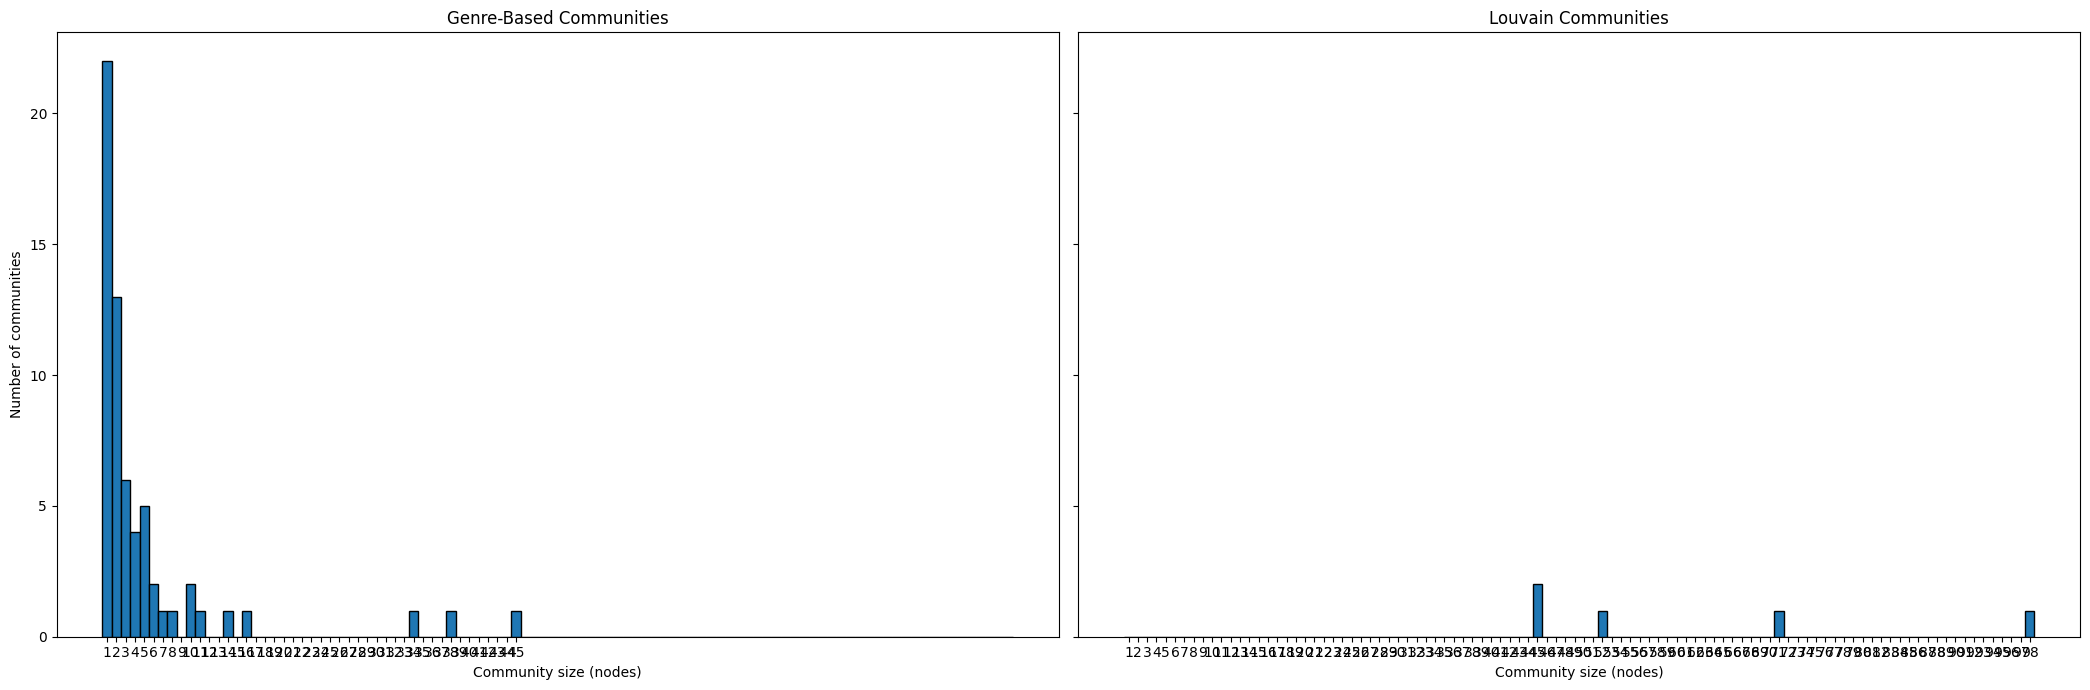

In [ ]:
# Display histogram of community sizes based on genres vs. Louvain communities
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from collections import defaultdict
import community as community_louvain
from networkx.algorithms.community import modularity

# Convert to undirected graph
G_undir = G.to_undirected()

# -------------------------------
# Filter nodes with at least one genre
# -------------------------------
nodes_with_genre = [n for n, data in G_undir.nodes(data=True) if data.get('genre')]
G_filtered = G_undir.subgraph(nodes_with_genre).copy()

# -------------------------------
# Create genre-based communities (first genre only)
# -------------------------------
communities = defaultdict(list)
for node, data in G_filtered.nodes(data=True):
    first_genre = data['genre'][0]  # take only the first genre
    communities[first_genre].append(node)

genre_communities = [set(nodes) for nodes in communities.values()]

print(f"Number of genre-based communities: {len(genre_communities)}")
print(f"Average genre-based community size: {np.mean([len(c) for c in genre_communities]):.2f}")

# -------------------------------
# Manual modularity function
# -------------------------------
def manual_modularity(G, communities):
    L = G.number_of_edges()  # total edges
    M = 0.0

    for community in communities:
        k_c = sum(dict(G.degree(community)).values())
        L_c = G.subgraph(community).number_of_edges()
        M += (L_c / L) - (k_c / (2*L))**2

    return M

print(f"Modularity of genre-based partition: {manual_modularity(G_filtered, genre_communities):.4f}")

# -------------------------------
# Keep only connected nodes for Louvain
# -------------------------------
G_connected = G_filtered.subgraph([n for n in G_filtered.nodes() if G_filtered.degree(n) > 0]).copy()

# -------------------------------
# Louvain community detection
# -------------------------------
partition_dict = community_louvain.best_partition(G_connected)
comm_dict = defaultdict(set)
for node, comm_id in partition_dict.items():
    comm_dict[comm_id].add(node)

louvain_communities = list(comm_dict.values())


mod_score = modularity(G_connected, louvain_communities)
print(f"\nNumber of Louvain communities: {len(louvain_communities)}")
print(f"Average Louvain community size: {np.mean([len(c) for c in louvain_communities]):.2f}")
print(f"Modularity of Louvain partition: {mod_score:.4f}")

# -------------------------------
# Compute community sizes
# -------------------------------
genre_community_sizes = [len(c) for c in genre_communities]
louvain_community_sizes = [len(c) for c in louvain_communities]

# Use shared bins for comparison
max_size = max(max(genre_community_sizes), max(louvain_community_sizes))
bins = range(1, max_size + 2)

# -------------------------------
# Plot histograms side by side
# -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(21, 7), sharey=True)

# Genre-based histogram
axes[0].hist(genre_community_sizes, bins=bins, edgecolor='black', align='left')
axes[0].set_xlabel('Community size (nodes)')
axes[0].set_ylabel('Number of communities')
axes[0].set_title('Genre-Based Communities')
axes[0].set_xticks(range(1, max(genre_community_sizes)+1))

# Louvain-based histogram
axes[1].hist(louvain_community_sizes, bins=bins, edgecolor='black', align='left')
axes[1].set_xlabel('Community size (nodes)')
axes[1].set_title('Louvain Communities')
axes[1].set_xticks(range(1, max(louvain_community_sizes)+1))

plt.tight_layout()
plt.show()

Examining the results in more detail, the genre-based approach yielded 62 communities with an average size of 5.08 nodes. Many of these communities consist of only 1 or 2 artists, which is reflected in the left histogram showing a large number of very small communities. This explains the relatively low modularity of ~0.10, as small, sparsely connected groups contribute little to the network's overall cohesion.

In contrast, the Louvain algorithm produced 5 larger communities with an average size of ~62 nodes, and a significantly higher modularity of ~0.36. The corresponding histogram shows fewer but much larger communities, highlighting that Louvain identifies dense clusters that span multiple genres. This difference illustrates how the choice of method strongly affects community size distribution and network structure interpretation. The resolution parameter in the Louvain method controls the granularity of detected communities. Higher values favor smaller communities, while lower values favor larger ones. In this analysis, and after having experimented with other resolution values, we used the default `networkx` one (1), which appeared to maximize modularity in our specific case.

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.colors as mcolors
import matplotlib.cm as cm

try:
    import fa2

    # --- ForceAtlas2 layout (shared for both plots) ---
    forceatlas2 = fa2.ForceAtlas2()
    pos_fa2 = forceatlas2.forceatlas2_networkx_layout(G_connected, iterations=2000)

    # --- 1. Genre-based Partition ---
    cmap = cm.get_cmap('tab20', len(communities))  # 'tab20' can handle 20, but we can interpolate
    genre_to_color = {genre: cmap(i) for i, genre in enumerate(communities.keys())}
    node_colors_genre = [genre_to_color[data['genre'][0]] for _, data in G_connected.nodes(data=True)]

    # --- 2. Louvain-based Partition ---
    color_map = plt.cm.tab10
    unique_comms = list(set(partition_dict.values()))
    node_colors_comm = [color_map(unique_comms.index(partition_dict[node])) for node in G_connected.nodes()]

    # --- Create side-by-side plots ---
    fig, axes = plt.subplots(1, 2, figsize=(20, 9))

    # --- Left: Genre Partition ---
    nx.draw_networkx_nodes(G_connected, pos_fa2, node_color=node_colors_genre, node_size=200, ax=axes[0])
    nx.draw_networkx_edges(G_connected, pos_fa2, alpha=0.5, ax=axes[0])
    axes[0].set_title("Network Partitioned by First Genre")
    axes[0].axis('off')

    # --- Right: Louvain Partition ---
    nx.draw_networkx_nodes(G_connected, pos_fa2, node_color=node_colors_comm, node_size=200, ax=axes[1])
    nx.draw_networkx_edges(G_connected, pos_fa2, alpha=0.5, ax=axes[1])
    axes[1].set_title("Network Partitioned by Louvain Communities")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
    print("Fig. 5: Comparison of Genre-based and Louvain-based Partitions (both with ForceAtlas2 Layout)")

except ModuleNotFoundError:
    print("Module 'fa2' not found — install it with: pip install fa2")


NameError: name 'fa2' is not defined

Fig. 5 shows that the partition obtained with Louvain communities is much more distinct and cohesive than the genre-based grouping. While the genre-based communities are numerous and mostly very small (and because there are so many groups, the colors had to be interpolated to distinguish them visually) the Louvain partition identifies fewer but larger communities with denser internal connections.

In [ ]:
import urllib.request
from collections import defaultdict

# GitHub base URL for rock_pages
ROCK_PAGES_BASE = 'https://raw.githubusercontent.com/Stonej29/02805/main/files/rock_pages/'

# Step 1: Aggregate text per structural community
community_texts = defaultdict(list)

# Get artist names from the partition_dict (which contains all artists in the graph)
for artist_name in partition_dict.keys():
    # Construct the filename and URL
    filename = artist_name.replace(' ', '_') + '.txt'
    file_url = ROCK_PAGES_BASE + filename
    
    try:
        # Fetch the file from GitHub
        with urllib.request.urlopen(file_url) as response:
            text = response.read().decode('utf-8')
        
        # Find which Louvain community this artist belongs to
        comm_id = partition_dict.get(artist_name)
        if comm_id is not None:
            community_texts[comm_id].append(text)
    except Exception as e:
        print(f"Could not fetch {filename}: {e}")
        continue

# Step 2: Combine texts for each community into a single string
for comm_id in community_texts:
    community_texts[comm_id] = ' '.join(community_texts[comm_id])

# Step 3: Create directory to store community texts
output_dir = "../files/structural_texts"
os.makedirs(output_dir, exist_ok=True)

# Step 4: Save community documents as .txt files
for comm_id, text in community_texts.items():
    safe_comm = f"community_{comm_id}"
    filename = os.path.join(output_dir, f"{safe_comm}.txt")
    with open(filename, "w", encoding="utf-8") as f:
        f.write(text)

print(f"Saved {len(community_texts)} community documents in '{output_dir}'")

NameError: name 'partition_dict' is not defined

In [ ]:
from collections import Counter
import numpy as np
import pandas as pd

# --- Step 1: Identify top genres and top communities dynamically ---
num_top = 7  # Max number of top genres / communities to show

# Collect all genres (consider *all* genres per node)
all_genres = [
    g
    for _, data in G_connected.nodes(data=True)
    if data.get('genre')
    for g in data['genre']
]

# Top genres
top_genres = [g for g, _ in Counter(all_genres).most_common(num_top)]
num_genres = len(top_genres)

# Top Louvain communities by size
community_sizes = Counter(partition_dict.values())
top_communities = [c for c, _ in community_sizes.most_common(num_top)]
num_communities = len(top_communities)

# --- Step 2: Initialize matrix ---
D = np.zeros((num_genres, num_communities), dtype=int)
genre_to_idx = {g: i for i, g in enumerate(top_genres)}
comm_to_idx = {c: i for i, c in enumerate(top_communities)}

# --- Step 3: Populate matrix ---
for node, data in G_connected.nodes(data=True):
    genres = data.get('genre', [])
    comm = partition_dict.get(node)
    
    # Ignore nodes not in top communities
    if comm not in top_communities:
        continue

    # Filter genres to top genres
    valid_genres = [g for g in genres if g in top_genres]
    if not valid_genres:
        continue

    for g in valid_genres:
        i = genre_to_idx[g]
        j = comm_to_idx[comm]
        D[i, j] += 1

# --- Step 4: Convert to DataFrame ---
df = pd.DataFrame(
    D,
    index=top_genres,
    columns=[f"Community {i+1}" for i in range(num_communities)]
)

# --- Step 5: Optional - collect node names per community ---
comm_nodes = defaultdict(list)
for node, comm in partition_dict.items():
    if comm in top_communities:
        comm_nodes[comm].append(node)

# --- Step 6: Visualization ---
plt.figure(figsize=(10, 6))
sns.heatmap(df, annot=True, fmt="d", cmap="YlGnBu", cbar=True)
plt.title("Confusion Matrix: First-Genre Communities vs Louvain Communities")
plt.ylabel("First-Genre Communities")
plt.xlabel("Louvain Communities")
plt.tight_layout()
plt.show()

NameError: name 'partition_dict' is not defined

In [ ]:
# Communities to inspect
for comm_id in [5]:
    nodes_in_comm = comm_nodes.get(top_communities[comm_id-1], [])
    
    # Collect all genres for these nodes
    genres_in_comm = set()
    for node in nodes_in_comm:
        node_genres = G_connected.nodes[node].get('genre', [])
        genres_in_comm.update(node_genres)
    
    print(f"Genres in Community {comm_id}: {sorted(genres_in_comm)}")

Genres in Community 5: ['contemporary r&b', 'funk', 'funk rock', 'psychedelic funk', 'psychedelic soul', 'routledge']


Overall, we observe that the Louvain communities do not align neatly with the initial genre-based groups. For instance, while some communities show a noticeable concentration of e.g. hard rock artists, most communities are highly mixed, and the connections between them do not appear to correspond strongly to first genre. Also, some communities are not associated at all with the most popular genres, like 5. If Louvain communities aligned perfectly with genres, the confusion matrix would show a strong block-diagonal pattern, with each genre concentrated in a single community and minimal off-diagonal counts. In reality, the counts are spread across communities, showing that most Louvain clusters mix genres. This reflects that Louvain captures structural connectivity rather than simply reproducing genre labels.

# Part 3: TF-IDF to understand genres and communities 

The questions below  are based on Lecture 7, part 2, 4, 5, 6 (and a little bit on part 3).

* Explain the concept of TF-IDF in your own words and how it can help you understand the genres and communities.
* Calculate and visualize TF-IDF for the genres and communities.
* Use the matrix $D$ (Lecture 7, part 2) to dicusss the difference between the word-clouds between genres and communities.

TF-IDF (Term Frequency–Inverse Document Frequency) is a statistical measure that evaluates how important a word is to a particular document within a collection. It combines two components: TF, which measures how often a word appears in a document, and IDF, which downweights words that are common across all documents. As a result, TF-IDF highlights words that are both frequent in a specific document and relatively rare across the corpus. In our context, TF-IDF helps identify the most distinctive or characteristic terms for each genre or structural community while ignoring common words like "the" or "a". For example, words with high TF-IDF scores in one community reveal the unique themes or vocabulary that set that group apart from others.

[nltk_data] Downloading package punkt_tab to /home/jyanes/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/jyanes/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



blues rock: 4548 words (TF-IDF weighted)
Top 10 TF-IDF words:
  coverdale: 220.83
  joplin: 178.79
  caserta: 167.24
  whitesnake: 165.84
  ccr: 114.85
  fogerty: 112.80
  yardbirds: 106.70
  meg: 105.74
  titleacdc: 97.78
  mcvie: 97.13

soft rock: 4131 words (TF-IDF weighted)
Top 10 TF-IDF words:
  gees: 125.29
  laine: 125.24
  frey: 120.55
  shorrock: 104.42
  mcvie: 93.46
  ambrosia: 88.52
  gramm: 87.89
  titleelton: 81.72
  goble: 80.63
  hodgson: 78.00

alternative metal: 5837 words (TF-IDF weighted)
Top 10 TF-IDF words:
  cornell: 258.69
  titlemarilyn: 206.19
  veil: 182.15
  primus: 176.84
  brides: 168.43
  korn: 141.91
  sevenfold: 136.39
  keenan: 124.23
  manson: 114.70
  claypool: 114.26

pop music: 5399 words (TF-IDF weighted)
Top 10 TF-IDF words:
  lavigne: 438.23
  orbison: 372.01
  rollers: 297.75
  amburn: 192.98
  titleavril: 182.40
  avril: 135.15
  mccartney: 129.08
  gees: 126.10
  jardine: 113.67
  dragons: 112.72

folk rock: 3462 words (TF-IDF weighted)
Top 

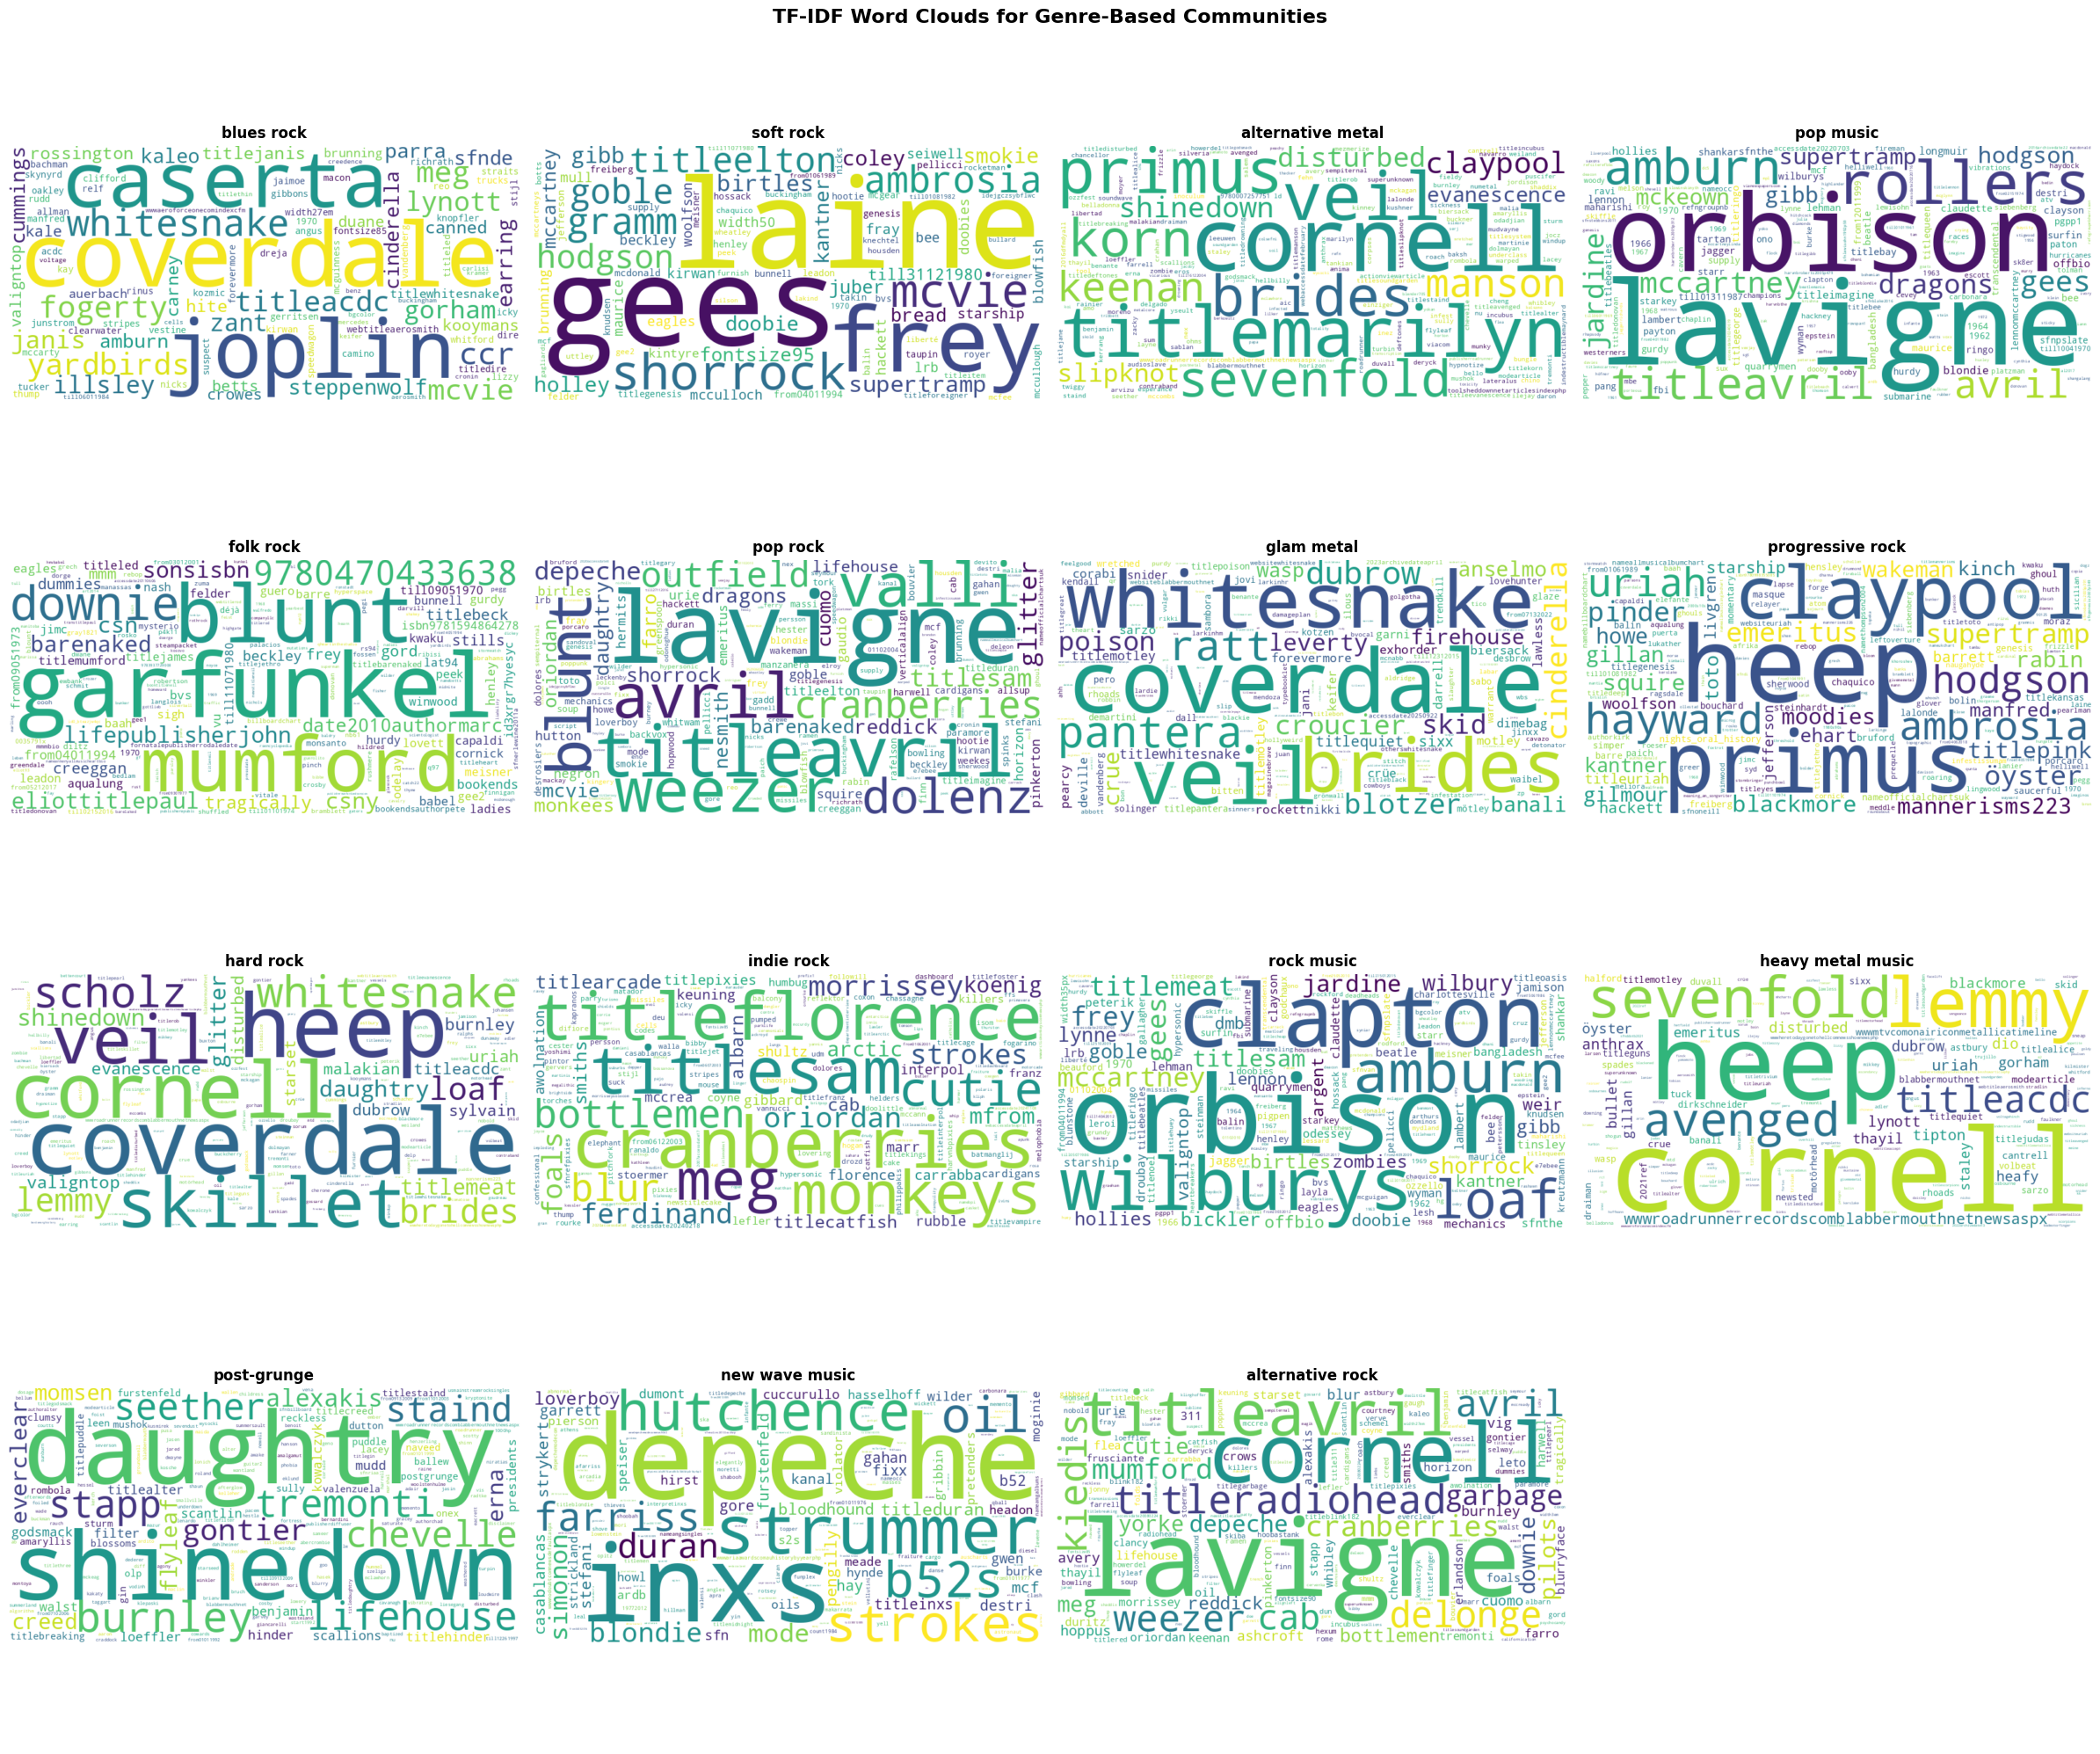

In [ ]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import math

nltk.download('punkt_tab')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
output_dir = "../files/top_15_genre_texts"

# read all genre documents and tokenize
documents = {}
for filename in os.listdir(output_dir):
    if not filename.endswith(".txt"):
        continue
    genre = os.path.splitext(filename)[0].replace("_", " ")
    filepath = os.path.join(output_dir, filename)
    with open(filepath, "r", encoding="utf-8") as f:
        text = f.read()

    tokens = word_tokenize(text)
    tokens = [re.sub(r'\W+', '', t.lower()) for t in tokens if re.sub(r'\W+', '', t)]
    tokens = [t for t in tokens if t not in stop_words]

    documents[genre] = tokens

# compute document frequencies
df_counts = Counter()
for tokens in documents.values():
    unique_words = set(tokens)
    for word in unique_words:
        df_counts[word] += 1

N = len(documents)

# compute TF-IDF per genre document
genre_tfidf = {}

for genre, tokens in documents.items():
    tf_counts = Counter(tokens)
    tfidf_scores = {}

    for word, tf in tf_counts.items():
        idf = math.log(N / (1 + df_counts[word]))
        tfidf_scores[word] = tf * idf

    tfidf_scores = {
        word: score
        for word, score in tfidf_scores.items()
        if tf_counts[word] >= 5
        and word.lower() not in {'cite', 'ref', 'urlhttps', 'album', 'band', 'name', 'web'}
        and 'http' not in word.lower()
        and 'url' not in word.lower()
    }

    genre_tfidf[genre] = tfidf_scores

# create combined figure with all word clouds
num_genres = len(genre_tfidf)
cols = int(np.ceil(np.sqrt(num_genres)))
rows = int(np.ceil(num_genres / cols))

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axes = axes.flatten() if num_genres > 1 else [axes]

for idx, (genre, tfidf_scores) in enumerate(genre_tfidf.items()):
    wc = WordCloud(width=800, height=400, background_color='white')
    wc.generate_from_frequencies(tfidf_scores)

    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(f"{genre}", fontsize=12, fontweight='bold')
    axes[idx].axis('off')

for idx in range(num_genres, len(axes)):
    axes[idx].axis('off')

plt.suptitle("TF-IDF Word Clouds for Genre-Based Communities", fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

[nltk_data] Downloading package punkt to /home/jyanes/nltk_data...
[nltk_data]   Package punkt is already up-to-date!



community 1: 10495 words (TF-IDF weighted)
Top 10 TF-IDF words:
  orbison: 506.46
  clapton: 310.59
  amburn: 212.03
  garfunkel: 190.06
  frey: 163.58
  valens: 145.02
  ub40: 145.02
  knopfler: 135.13
  rollers: 130.31
  gees: 129.75

community 2: 7832 words (TF-IDF weighted)
Top 10 TF-IDF words:
  gentry: 140.62
  coverdale: 105.42
  scholz: 93.38
  veil: 92.04
  heep: 80.69
  whitesnake: 80.22
  modearticle: 68.93
  loverboy: 62.62
  earring: 61.52
  peterik: 57.13

community 3: 323 words (TF-IDF weighted)
Top 10 TF-IDF words:
  funkadelic: 67.24
  pfunk: 49.91
  parliaments: 40.65
  parliamentfunkadelic: 36.04
  larkinsm: 17.58
  haskins: 15.38
  plainfield: 14.28
  maggot: 13.18
  shider: 12.08
  westbound: 10.99

community 0: 10320 words (TF-IDF weighted)
Top 10 TF-IDF words:
  lavigne: 413.81
  cranberries: 188.96
  titleavril: 156.00
  cab: 146.95
  titleradiohead: 140.62
  hives: 126.34
  monkeys: 115.15
  hoppus: 101.07
  garbage: 98.93
  delonge: 98.88

community 5: 6030 w

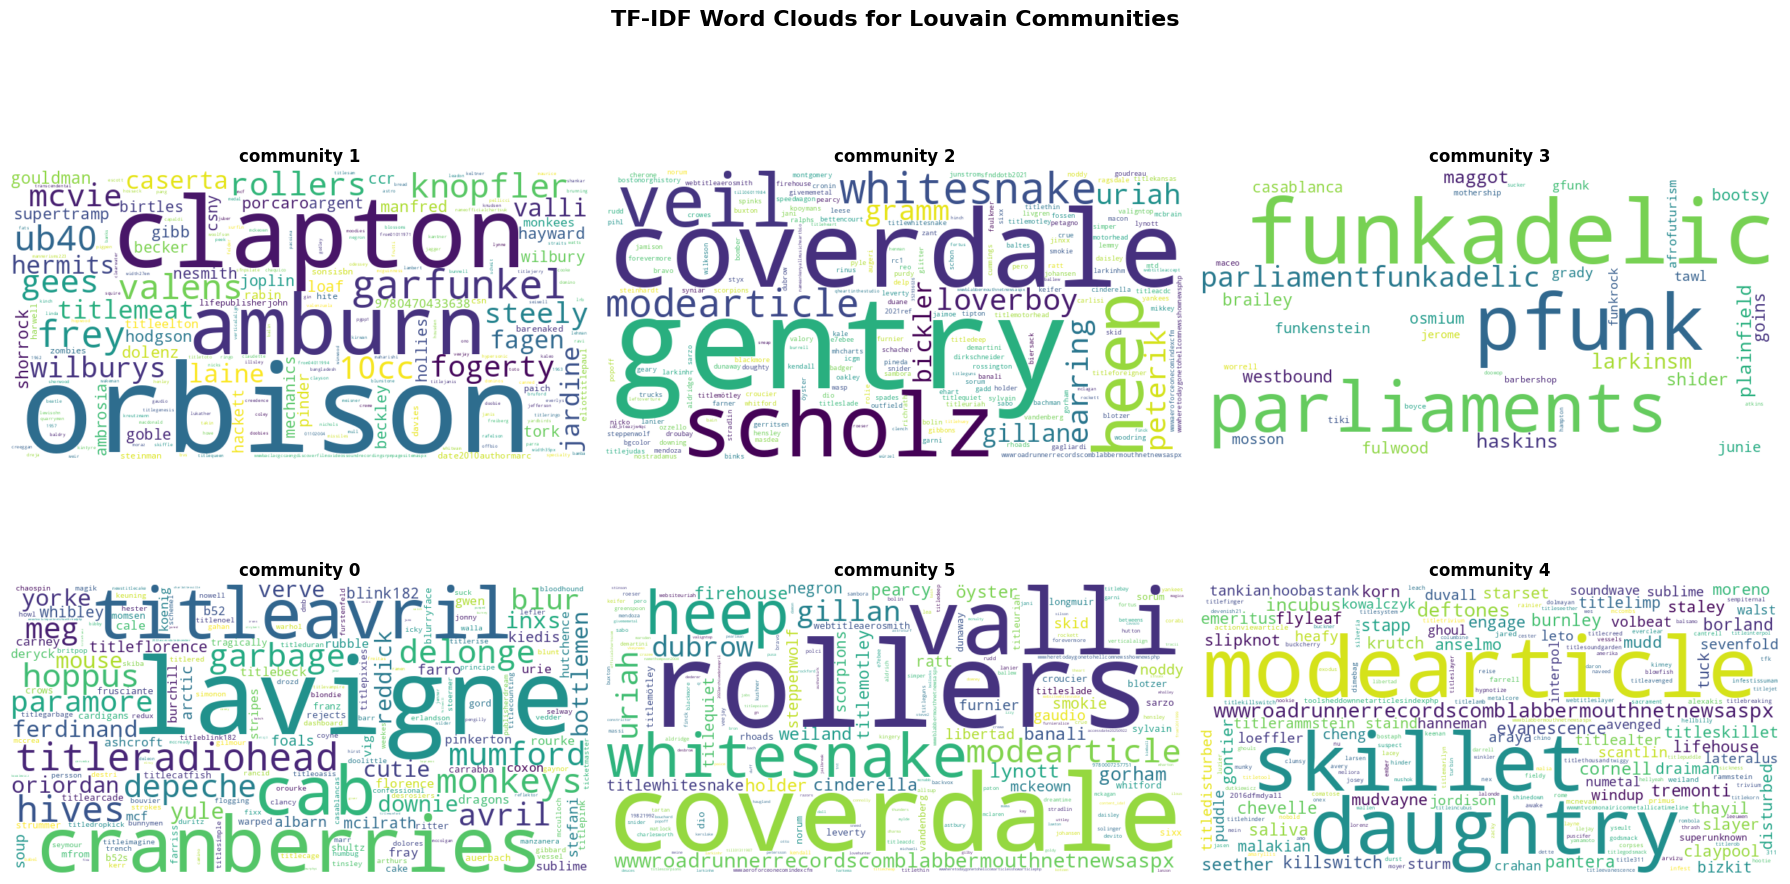

In [ ]:
import os
import re
from collections import Counter, defaultdict
import math

import nltk
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
import matplotlib.pyplot as plt

nltk.download('punkt')

output_dir = "../files/structural_texts"

# read all texts and tokenize
documents = {}
for filename in os.listdir(output_dir):
    if not filename.endswith(".txt"):
        continue
    genre = os.path.splitext(filename)[0].replace("_", " ")
    filepath = os.path.join(output_dir, filename)
    with open(filepath, "r", encoding="utf-8") as f:
        text = f.read()
    tokens = word_tokenize(text)
    tokens = [re.sub(r'\W+', '', t.lower()) for t in tokens if re.sub(r'\W+', '', t)]
    documents[genre] = tokens

# compute document frequencies
df_counts = Counter()
for tokens in documents.values():
    unique_words = set(tokens)
    for word in unique_words:
        df_counts[word] += 1

N = len(documents)

# compute TF-IDF per document
community_tfidf = {}

for community, tokens in documents.items():
    tf_counts = Counter(tokens)
    tfidf_scores = {}
    for word, tf in tf_counts.items():
        idf = math.log(N / (1 + df_counts[word]))
        tfidf_scores[word] = tf * idf
    tfidf_scores = {
        w: score 
        for w, score in tfidf_scores.items() 
        if tf_counts[w] >= 5
        and w.lower() not in {'cite', 'ref', 'urlhttps', 'album', 'band', 'name', 'web'}
        and 'http' not in w.lower()
        and 'url' not in w.lower()
    }
    community_tfidf[community] = tfidf_scores

# create combined figure with all word clouds
num_communities = len(community_tfidf)
cols = int(np.ceil(np.sqrt(num_communities)))
rows = int(np.ceil(num_communities / cols))

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axes = axes.flatten() if num_communities > 1 else [axes]

for idx, (community, tfidf_scores) in enumerate(community_tfidf.items()):
    wc = WordCloud(width=800, height=400, background_color='white')
    wc.generate_from_frequencies(tfidf_scores)
    
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(f"{community}", fontsize=12, fontweight='bold')
    axes[idx].axis('off')

for idx in range(num_communities, len(axes)):
    axes[idx].axis('off')

plt.suptitle("TF-IDF Word Clouds for Louvain Communities", fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

As we have seen in the D matrix, there is no clear overlap between the genres and the communities. This can again be seen by comparing the word clouds of the genres vs the communities. If there would be an overlap, then we would expect to see the same words in similar proportions both in the genres and the communities. But they dont all aling. We can see that a few genres have prominent words that are also used often in a certain community like the word "lavigne" in community 0 and the genres pop music, pop rock and alternative rock. This lets us believe that those three genres likely lie in community 0 but they dont need to be enclosed in it.

# Part 4: Sentiment of the artists and communities

The questions below are based on Lecture 8

* Calculate the sentiment of the band/artist pages (it is OK to work with the sub-network of artists-with-genre) and describe your findings using stats and visualization, inspired by the first exercise of week 8.
* Discuss the sentiment of the communities. Do the findings using TF-IDF during Lecture 7 help you understand your results?

In [ ]:
# Load LabMT word list
import urllib.request
url = 'https://raw.githubusercontent.com/Stonej29/02805/main/files/Mechanical_Turk_1.0.txt'
with urllib.request.urlopen(url) as response:
    labmt_file = response.read().decode('utf-8')
#labmt_file = "../files/Mechanical_Turk_1.0.txt"
labmt_df = pd.read_csv(labmt_file, sep="\t", header=0, usecols=[0, 2], names=["word", "happiness_average"])
# Convert words to lowercase
labmt_df["word"] = labmt_df["word"].str.lower()
labmt_dict = dict(zip(labmt_df["word"], labmt_df["happiness_average"]))

# --- Function to compute sentiment per community folder ---
def compute_sentiment(tokens, labmt_dict):
    """
    Compute average sentiment for a list of tokens based on LabMT scores.
    
    Parameters:
        tokens (list of str): Tokens in lowercase.
        
    Returns:
        float: Average happiness of tokens found in LabMT. Returns None if no tokens match.
    """
    scores = [labmt_dict[t] for t in tokens if t in labmt_dict]
    if scores:
        return sum(scores) / len(scores)
    else:
        return None

OSError: [Errno 36] File name too long: "word\thappiness_rank\thappiness_average\thappiness_standard_deviation\ttwitter_rank\tgoogle_rank\tnyt_rank\tlyrics_rank\nlaughter\t1\t8.50\t0.9313\t3600\t--\t--\t1728\nhappiness\t2\t8.44\t0.9723\t1853\t2458\t--\t1230\nlove\t3\t8.42\t1.1082\t25\t317\t328\t23\nhappy\t4\t8.30\t0.9949\t65\t1372\t1313\t375\nlaughed\t5\t8.26\t1.1572\t3334\t3542\t--\t2332\nlaugh\t6\t8.22\t1.3746\t1002\t3998\t4488\t647\nlaughing\t7\t8.20\t1.1066\t1579\t--\t--\t1122\nexcellent\t8\t8.18\t1.1008\t1496\t1756\t3155\t--\nlaughs\t9\t8.18\t1.1551\t3554\t--\t--\t2856\njoy\t10\t8.16\t1.0568\t988\t2336\t2723\t809\nsuccessful\t11\t8.16\t1.0759\t2176\t1198\t1565\t--\nwin\t12\t8.12\t1.0812\t154\t3031\t776\t694\nrainbow\t13\t8.10\t0.9949\t2726\t--\t--\t1723\nsmile\t14\t8.10\t1.0152\t925\t2666\t2898\t349\nwon\t15\t8.10\t1.2164\t810\t1167\t439\t1493\npleasure\t16\t8.08\t0.9655\t1497\t1526\t4253\t1398\nsmiled\t17\t8.08\t1.0660\t--\t3537\t--\t2248\nrainbows\t18\t8.06\t1.3603\t--\t--\t--\t

In [ ]:
import re
import urllib.request
import networkx as nx
from nltk.tokenize import word_tokenize

# GitHub base URL for rock_pages
ROCK_PAGES_BASE = 'https://raw.githubusercontent.com/Stonej29/02805/main/files/rock_pages/'

# First, get the list of artist names from the graph nodes
# We'll use the nodes that are already in your network
# Alternatively, you can fetch from a specific list if you have it

# If you have a pre-defined list of artists, use that
# For now, let's assume we can get it from earlier in the notebook
# or we fetch it from the network file you already loaded

# Get artist names from the graph G that was loaded earlier
# (This assumes you've already loaded the network in a previous cell)
artist_names = list(G.nodes())
print(f"Loaded {len(artist_names)} artist names from the network.")

# Convert list to set for fast lookup
artist_set = set(artist_names)

# Regex to extract links
link_pattern = r"\[\[([^\|\]]+)(?:\|[^\]]*)?\]\]"

# Create a new graph to rebuild with full data
G_full = nx.DiGraph()

# Add all artists as nodes
G_full.add_nodes_from(artist_names)

# Fetch each artist's Wikipedia page from GitHub
for artist_name in artist_names:
    # Construct filename and URL
    filename = artist_name.replace(' ', '_') + '.txt'
    file_url = ROCK_PAGES_BASE + filename
    
    try:
        # Fetch the file from GitHub
        with urllib.request.urlopen(file_url) as response:
            text = response.read().decode('utf-8')
        
        # Word count
        word_count = len(re.findall(r'\b\w+\b', text))
        G_full.nodes[artist_name]['word_count'] = word_count

        # Extract all outgoing links
        outgoing_links = re.findall(link_pattern, text)
        for target in outgoing_links:
            target = target.replace('_', ' ')
            if target in artist_set:
                G_full.add_edge(artist_name, target)

        # --- Compute sentiment ---
        # Tokenize, lowercase, remove punctuation
        tokens = word_tokenize(text)
        tokens = [re.sub(r'\W+', '', t.lower()) for t in tokens if re.sub(r'\W+', '', t)]

        # Compute sentiment
        sentiment = compute_sentiment(tokens, labmt_dict)
        G_full.nodes[artist_name]['sentiment'] = sentiment
        
    except Exception as e:
        print(f"Could not fetch {filename}: {e}")
        continue

# Use the rebuilt graph
G = G_full

print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")
# Inspect sample nodes
sample_nodes = list(G.nodes(data=True))[:5]
for node, data in sample_nodes:
    print(node, data)

# Remove disconnected nodes
G.remove_nodes_from(list(nx.isolates(G)))

# Extract the largest weakly connected component
largest_wcc_nodes = max(nx.weakly_connected_components(G), key=len)
G = G.subgraph(largest_wcc_nodes).copy()

# Manually remove node "AllMusic" as it was unintentionally included
if "AllMusic" in G:
    G.remove_node("AllMusic")
    print("Removed node 'AllMusic'.")
print(f"Final graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Loaded 487 artist names from the network.
Could not fetch Bay_City_Rollers.txt: name 'compute_sentiment' is not defined
Could not fetch Foals_(band).txt: name 'compute_sentiment' is not defined
Could not fetch Steve_Vai.txt: name 'compute_sentiment' is not defined
Could not fetch The_Fray.txt: name 'compute_sentiment' is not defined
Could not fetch Gary_Glitter.txt: name 'compute_sentiment' is not defined
Could not fetch Korn.txt: name 'compute_sentiment' is not defined
Could not fetch Mudvayne.txt: name 'compute_sentiment' is not defined
Could not fetch Blues_Traveler.txt: name 'compute_sentiment' is not defined
Could not fetch Slipknot_(band).txt: name 'compute_sentiment' is not defined
Could not fetch Funkadelic.txt: name 'compute_sentiment' is not defined
Could not fetch Parliament_(band).txt: name 'compute_sentiment' is not defined
Could not fetch Rod_Stewart.txt: name 'compute_sentiment' is not defined
Could not fetch Poison_(American_band).txt: name 'compute_sentiment' is not de

KeyboardInterrupt: 

In [ ]:
# Calculate sentiment for all nodes now that compute_sentiment is defined
for node in G.nodes():
    if 'text' in G.nodes[node]:
        text = G.nodes[node]['text']
        # Tokenize, lowercase, remove punctuation
        tokens = word_tokenize(text)
        tokens = [re.sub(r'\W+', '', t.lower()) for t in tokens if re.sub(r'\W+', '', t)]
        
        # Compute sentiment
        sentiment = compute_sentiment(tokens, labmt_dict)
        G.nodes[node]['sentiment'] = sentiment

print("Sentiment calculation complete!")

NameError: name 'compute_sentiment' is not defined

Mean sentiment in the graph: 5.5714
Median sentiment in the graph: 5.5731
Variance in sentiment in the graph: 0.0040
25th percentile sentiment: 5.5326
75th percentile sentiment: 5.6114


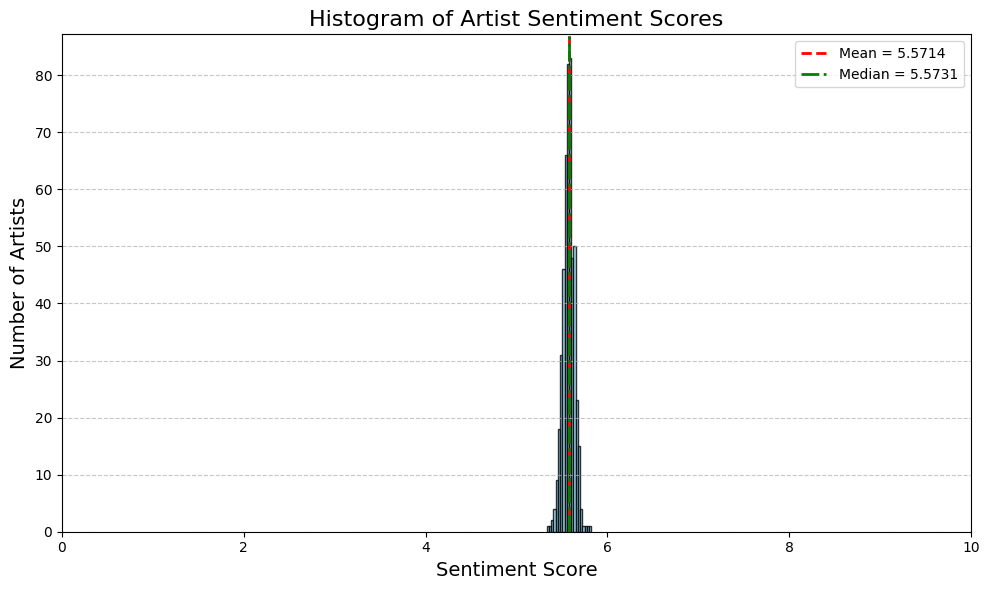

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate mean sentiment in the graph
sentiments = [data['sentiment'] for node, data in G.nodes(data=True) if data['sentiment'] is not None]
if sentiments:
    mean_sentiment = sum(sentiments) / len(sentiments)
    print(f"Mean sentiment in the graph: {mean_sentiment:.4f}")
    print(f"Median sentiment in the graph: {sorted(sentiments)[len(sentiments)//2]:.4f}")
    print(f"Variance in sentiment in the graph: {sum((x - mean_sentiment) ** 2 for x in sentiments) / len(sentiments):.4f}")
    print(f"25th percentile sentiment: {sorted(sentiments)[int(0.25 * len(sentiments))]:.4f}")
    print(f"75th percentile sentiment: {sorted(sentiments)[int(0.75 * len(sentiments))]:.4f}")

# Extract sentiment scores
sentiment_values = [data['sentiment'] for node, data in G.nodes(data=True) if data['sentiment'] is not None]

# Compute statistics
mean_sent = np.mean(sentiment_values)
median_sent = np.median(sentiment_values)
std_sent = np.std(sentiment_values)

# Plot histogram
plt.figure(figsize=(10,6))
plt.hist(sentiment_values, bins=20, color='skyblue', edgecolor='black', alpha=0.8)

# Add vertical lines for mean and median
plt.axvline(mean_sent, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_sent:.4f}')
plt.axvline(median_sent, color='green', linestyle='-.', linewidth=2, label=f'Median = {median_sent:.4f}')

plt.title("Histogram of Artist Sentiment Scores", fontsize=16)
plt.xlabel("Sentiment Score", fontsize=14)
plt.ylabel("Number of Artists", fontsize=14)
plt.xlim(0, 10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
import pandas as pd
import urllib.request
    
def compute_community_sentiments_from_github(base_url, labmt_dict, file_list, top_n=15):
    community_sentiments = {}
    documents = {}

    # Limit to top N if necessary
    files = file_list[:top_n] if len(file_list) > top_n else file_list

    # Fetch and read all documents from GitHub
    for filename in files:
        comm_name = os.path.splitext(filename)[0]
        file_url = base_url + filename
        
        try:
            with urllib.request.urlopen(file_url) as response:
                text = response.read().decode('utf-8')
                documents[comm_name] = text
        except Exception as e:
            print(f"Could not fetch {filename}: {e}")
            continue

    # Compute sentiment for each
    for comm_name, text in documents.items():
        tokens = word_tokenize(text)
        tokens = [re.sub(r'\W+', '', t.lower()) for t in tokens if re.sub(r'\W+', '', t)]
        sentiment = compute_sentiment(tokens, labmt_dict)
        community_sentiments[comm_name] = sentiment

    return community_sentiments


# --- GitHub URLs ---
STRUCTURAL_TEXTS_BASE = 'https://raw.githubusercontent.com/Stonej29/02805/main/files/structural_texts/'
GENRE_TEXTS_BASE = 'https://raw.githubusercontent.com/Stonej29/02805/main/files/top_15_genre_texts/'

# Define the list of files (you'll need to specify which files exist)
# For structural/Louvain communities (community_0.txt, community_1.txt, etc.)
louvain_files = [f"community_{i}.txt" for i in range(10)]  # Adjust range based on your communities

# For genre communities - specify your genre files
genre_files = [
    "alternative_rock.txt",
    "hard_rock.txt", 
    "heavy_metal.txt",
    "punk_rock.txt",
    "progressive_rock.txt",
    # Add all your genre file names here
]

# Compute sentiments
louvain_sentiments = compute_community_sentiments_from_github(STRUCTURAL_TEXTS_BASE, labmt_dict, louvain_files)
genre_sentiments = compute_community_sentiments_from_github(GENRE_TEXTS_BASE, labmt_dict, genre_files)

# --- Plot side-by-side comparison ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Louvain
axes[0].bar(louvain_sentiments.keys(), louvain_sentiments.values(), color='steelblue', edgecolor='black')
axes[0].set_title("Average Sentiment per Louvain Community", fontsize=12)
axes[0].set_xticklabels(louvain_sentiments.keys(), rotation=45, ha='right')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].set_ylabel("Average Sentiment Score")

# Genre
axes[1].bar(genre_sentiments.keys(), genre_sentiments.values(), color='coral', edgecolor='black')
axes[1].set_title("Average Sentiment per Genre-Based Community", fontsize=12)
axes[1].set_xticklabels(genre_sentiments.keys(), rotation=45, ha='right')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle("Comparison of Average Sentiment Across Community Types", fontsize=14)
plt.tight_layout()
plt.show()

# --- Summary statistics ---
def print_sentiment_summary(name, sentiments):
    scores = list(sentiments.values())
    mean_sent = np.mean(scores)
    median_sent = np.median(scores)
    std_sent = np.std(scores)
    happiest = max(sentiments, key=sentiments.get)
    saddest = min(sentiments, key=sentiments.get)

    print(f"\n{name} Communities Summary:")
    print(f"  Mean sentiment: {mean_sent:.2f}")
    print(f"  Median sentiment: {median_sent:.2f}")
    print(f"  Std. deviation: {std_sent:.2f}")
    print(f"  Happiest: {happiest} ({sentiments[happiest]:.2f})")
    print(f"  Saddest: {saddest} ({sentiments[saddest]:.2f})")

print_sentiment_summary("Louvain", louvain_sentiments)
print_sentiment_summary("Genre-based", genre_sentiments)

NameError: name 'labmt_dict' is not defined

In [ ]:
# happiest and saddest artists
sorted_artists = sorted([(node, data['sentiment']) for node, data in G.nodes(data=True) 
                         if data.get('sentiment') is not None],
                       key=lambda x: x[1], reverse=True)

sorted_artists_reverse = sorted([(node, data['sentiment']) for node, data in G.nodes(data=True) 
                         if data.get('sentiment') is not None],
                       key=lambda x: x[1], reverse=False)

print("Top 10 Happiest Artist Pages")
for i, (artist, score) in enumerate(sorted_artists[:10], 1):
    print(f"{i:2d}. {artist:50s} - Score: {score:.4f}")

print("Top 10 Saddest Artist Pages")
for i, (artist, score) in enumerate(sorted_artists_reverse[:10], 1):
    print(f"{i:2d}. {artist:50s} - Score: {score:.4f}")

TOP 10 HAPPIEST ARTIST PAGES
TOP 10 SADDEST ARTIST PAGES


The average sentiment across both Louvain structural communities and first-genre-based communities are very close (≈5.5-5.6). This suggests that, at the textual level of Wikipedia pages, there is little variation in word usage that distinguishes one community from another. In other words, most artist pages contain similar general information-biographical details, discography, and references to other artists, so the documents are textually homogeneous. For deeper insights into genre-specific or emotional content, lyrics analysis may be more discriminative than Wikipedia biographical pages.
Looking at the specific artists, we can see that there is a biggere difference in sentiment. For example, Tracy Chapman has the highest sentiment of all artists. This can be explained by looking at her wikipedia entry. She mainly writes music in the folk and pop genre. On the other side, Gray Glitter has the lowest sentiment. This is likely due to his crimial past. Words like "Imprisoned" have a negative sentiment, dragging his while sentiment down by a bit.

## Contribution Statement

All group members contributed equally to this project. We each worked through all exercises individually, then came together to discuss solutions, share approaches, and refine our work. The final version reflects the combined effort and agreement of the entire team.